<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Geethika_buridi/My_project_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Name:** AirFly Insights: Data Visualization and Analysis of Airline Operations.

**Project Statement:**
The objective of this project is to analyze large-scale airline flight data to uncover operational
trends, delay patterns, and cancellation reasons using data visualization techniques. The goal
is to help understand airline and airport-level performance and contribute to actionable
insights using visual analysis.

**Expected Outcomes:**
1. Understand and preprocess aviation datasets for analysis
2. Explore trends in flight schedules, delays, cancellations, and routes
3. Visualize key metrics using bar charts, time series, heatmaps, maps, and comparisons
4. Provide insights for stakeholders including airline operators and analysts
5. Summarize findings through a final visual report and presentation.

**Dataset:** 2015 flight delays and cancellations.
Link:https://www.kaggle.com/datasets/usdot/flight-delays

**Modules to be Implemented:**
1. Data Acquisition and Understanding
2. Data Cleaning and Feature Engineering
3. Univariate and Bivariate Analysis
4. Delay Cause Analysis
5. Cancellation and Seasonal Trends
6. Airport and Route-Level Exploration
7. Final Dashboard or Report
8. Documentation and Presentation

**Week-wise Implementation Plan**
**Milestone 1:** Data Foundation and Cleaning

 **Week 1:** Project Initialization and Dataset Setup
  1.  Define goals, KPIs, and workflow
  2.  Load CSVs using pandas
  3.  Explore schema, types, size, and nulls
  4.  Perform sampling and memory optimizations

**Week 2:** Preprocessing and Feature Engineering
  1.  Handle nulls in delay and cancellation columns
  2.  Create derived features: Month, Day of Week, Hour, Route
  3.  Format datetime columns
  4. Save preprocessed data for fast reuse

**Deliverables:**
  1. Cleaned dataset
  2. Summary of preprocessing logic
  3. Feature dictionary

**Milestone 2: Visual Exploration and Delay Trends**

**Week 3: Univariate and Bivariate Visual Analysis**
1. Top airlines, routes, and busiest months
2. Flight distribution by day, time, and airport
3. Plot bar charts, histograms, boxplots, and line plots

**Week 4: Delay Analysis - Airline and Weather**
1. Compare delay causes by airline
2. Explore carrier delays, weather delays, NAS delays
3. Visualize delays by time of day and airport

**Deliverables:**
1. Set of visualizations (minimum 8)
2. Observations on peak delays and top delay-prone carriers

**Week-1:Project Initialization and Dataset Setup**

**1.Importing Required Libraries**

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2 )
%matplotlib inline
plt.style.use('seaborn-v0_8')

**2.Loading CSV files and checking Total no.of rows and columns**

In [112]:
airlines = pd.read_csv("/content/airlines.csv")
airlines.shape

(14, 2)

In [113]:
airports = pd.read_csv("/content/airports.csv")
airports.shape

(322, 7)

In [114]:
flights = pd.read_csv("/content/flights.csv")
flights.shape


(5819079, 31)

**Performing Sampling**

In [115]:
# WEEK 1 – SAMPLING (as mentioned in project document)
print("Original dataset shape :", flights.shape)        # ~5.8 million rows

# Taking a representative sample of 5 lakh rows (still huge + accurate)
# Using random_state for reproducibility
flights_sample = flights.sample(n=500_000, random_state=42)

print("Sampled dataset shape :", flights_sample.shape)
print("We reduced from 5.8 million → 5 lakh rows while keeping all patterns intact.")
print("Sampling done as per Week-1 requirement in project document")

# Now continue all analysis on flights_sample instead of full flights
flights = flights_sample.copy()

# Optional: Also show memory reduction
print(f"\nMemory usage after sampling: {flights.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Original dataset shape : (5819079, 31)
Sampled dataset shape : (500000, 31)
We reduced from 5.8 million → 5 lakh rows while keeping all patterns intact.
Sampling done as per Week-1 requirement in project document

Memory usage after sampling: 0.21 GB


 **Analysing Memory usuage of flights dataset**

In [116]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1508570 to 4592877
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 500000 non-null  int64  
 1   MONTH                500000 non-null  int64  
 2   DAY                  500000 non-null  int64  
 3   DAY_OF_WEEK          500000 non-null  int64  
 4   AIRLINE              500000 non-null  object 
 5   FLIGHT_NUMBER        500000 non-null  int64  
 6   TAIL_NUMBER          498704 non-null  object 
 7   ORIGIN_AIRPORT       500000 non-null  object 
 8   DESTINATION_AIRPORT  500000 non-null  object 
 9   SCHEDULED_DEPARTURE  500000 non-null  int64  
 10  DEPARTURE_TIME       492615 non-null  float64
 11  DEPARTURE_DELAY      492615 non-null  float64
 12  TAXI_OUT             492333 non-null  float64
 13  WHEELS_OFF           492333 non-null  float64
 14  SCHEDULED_TIME       500000 non-null  float64
 15  ELAPSED_TIME   

**Memory usage is 1.3+ GB**

**Memory optimization**

In [117]:
def reduce_mem_usage(flight, verbose=True):
    start_mem = flights.memory_usage().sum() / 1024**2

    for col in flights.columns:
        col_type = flights[col].dtype

        if col_type != object:
            c_min = flights[col].min()
            c_max = flights[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    flights[col] = flights[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    flights[col] = flights[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    flights[col] = flights[col].astype(np.int32)
            else:
                flights[col] = flights[col].astype(np.float32)
        else:
            flights[col] = flights[col].astype('category')

    if verbose:
        end_mem = flights.memory_usage().sum() / 1024**2
        print("Memory reduced from", round(start_mem, 2), "MB to", round(end_mem, 2), "MB")


    return flights

In [118]:
# now applying the memory optimization function
print("Optimizing memory for the full 5.8M flights dataset...")
flights = reduce_mem_usage(flights)    # calling the function

# now checking if memory actually reduced
print("\n" + "-"*55)
print("MEMORY OPTIMIZATION DONE SUCCESSFULLY")
print("-"*55)

# this will shows all columns with their new data types and memory
flights.info(memory_usage='deep')

# just printing final memory in GB so its easy to see
total_memory = flights.memory_usage(deep=True).sum() / (1024*1024*1024)
print("Final memory usage is around = ", round(total_memory,2), "GB")
print("-"*55)

Optimizing memory for the full 5.8M flights dataset...
Memory reduced from 122.07 MB to 45.54 MB

-------------------------------------------------------
MEMORY OPTIMIZATION DONE SUCCESSFULLY
-------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1508570 to 4592877
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 500000 non-null  int16   
 1   MONTH                500000 non-null  int8    
 2   DAY                  500000 non-null  int8    
 3   DAY_OF_WEEK          500000 non-null  int8    
 4   AIRLINE              500000 non-null  category
 5   FLIGHT_NUMBER        500000 non-null  int16   
 6   TAIL_NUMBER          498704 non-null  category
 7   ORIGIN_AIRPORT       500000 non-null  category
 8   DESTINATION_AIRPORT  500000 non-null  category
 9   SCHEDULED_DEPARTURE  500000 non-null  int16   
 10  DEPARTURE_

**Memory usage is reduced from 1.3+GB to 0.47GB.**

**Therefore Performed sampling and memory optimizations.**

**Analysing airlines dataset**

In [119]:
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


From Airlines Dataset.
1. IATA_CODE : The IATA code for airlines is a two-character code assigned by the International Air Transport Association (IATA) to uniquely identify airlines for purposes like reservations, ticketing, and baggage.
2. AIRLINE : The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.

In [120]:
airlines.columns

Index(['IATA_CODE', 'AIRLINE'], dtype='object')

In [121]:
airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes


In [122]:
airlines.isnull().sum()

,0
IATA_CODE,0
AIRLINE,0


In [123]:
airlines.describe()

,IATA_CODE,AIRLINE
count,14,14
unique,14,14
top,UA,United Air Lines Inc.
freq,1,1


In [124]:
airlines.dtypes

,0
IATA_CODE,object
AIRLINE,object


**Analysing airports Dataset**

In [125]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65,-75.44
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41,-99.68
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04,-106.61
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.45,-98.42
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.54,-84.19


1. IATA_CODE :IATA code is a unique three-letter code designated by the International Air Transport Association to identify airports, and sometimes cities, for passenger operations. These codes are used on tickets, boarding passes, and flight searches to easily identify a specific airport
2. AIRPORT :The name of the airport is stored in the airport column.
3. CITY : collections of data that link airports to the cities they serve, often including geographic and flight information
4. STATE :collections of data about the condition, status, and performance of airports, often covering a specific state or region
5. COUNTRY :The name of the country where the airport is located.
6. LATITUDE :The north-south position of the airport, measured in degrees, with positive values for the Northern Hemisphere and negative for the Southern Hemisphere.
7. LONGITUDE :The primary data point, representing the east-west position of the airport in decimal degrees. Positive values typically indicate east longitude, while negative values indicate west.

In [126]:
for column in airports.columns:
    print(column)

IATA_CODE
AIRPORT
CITY
STATE
COUNTRY
LATITUDE
LONGITUDE


In [127]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB


In [128]:
airports.describe()

,LATITUDE,LONGITUDE
count,319.00,319.00
mean,38.98,-98.38
std,8.62,21.52
min,13.48,-176.65
25%,33.65,-110.84
50%,39.30,-93.40
75%,43.15,-82.72
max,71.29,-64.80


In [129]:
airports.dtypes

,0
IATA_CODE,object
AIRPORT,object
CITY,object
STATE,object
COUNTRY,object
LATITUDE,float64
LONGITUDE,float64


In [130]:
airports.isnull().sum()

,0
IATA_CODE,0
AIRPORT,0
CITY,0
STATE,0
COUNTRY,0
LATITUDE,3
LONGITUDE,3


**Observation:** latitude and longitude has null values. we can't fill these null values.

**Analysing Flights Dataset**

In [131]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


1. YEAR - The year in which the flight was scheduled.
2. MONTH - The month of the flight (1-12).
3. DAY - The day of the month when the flight took place.
4. DAY_OF_WEEK - Numeric day of the week (1 = Monday, 7 = Sunday).
5. FLIGHT_NUMBER - The airline's assigned flight number.
6. TAIL_NUMBER - The aircraft's registration number (unique ID of airplane).
7. ORIGIN_AIRPORT - Airport code from where the flight departs.
8. DESTINATION_AIRPORT - Airport code where the flight lands.
9. SCHEDULED_DEPARTURE - Planned departure time (as per schedule).
10. DEPARTURE_TIME - Actual departure time.
11. DEPARTURE_DELAY - Minutes flight departed late (negative means early).
12. TAXI_OUT - Time in minutes the flight spent taxiing from gate to runway.
13. WHEELS_OFF - Time when the plane actually took off from the ground.
14. SCHEDULED_TIME - Scheduled total duration of the flight.
15. ELAPSED_TIME - Actual total time from takeoff to landing.
16. AIR_TIME - Time in the air only (does not include taxiing).
17. DISTANCE - Distance between origin and destination airports.
18. WHEELS_ON - Time when the aircraft touches the runway at arrival.
19. TAXI_IN - Time taken to taxi from runway to arrival gate.
20. SCHEDULED_ARRIVAL - Planned arrival time.
21. ARRIVAL_TIME - Actual arrival time.
22. ARRIVAL_DELAY - Minutes the flight arrived late (negative means early).
23. DIVERTED - Indicates if the flight was diverted to another airport (1 = yes).
24. CANCELLED - Indicates if the flight was cancelled (1 = yes).
25. CANCELLATION_REASON - Reason for cancellation (A, B, C, D) depending on dataset documentation.
26. AIR_SYSTEM_DELAY - Delay due to air traffic control or system issues.
27. SECURITY_DELAY - Delay caused by security reasons.
28. AIRLINE_DELAY - Delay caused by airline operations (crew, maintenance, etc.).
29. LATE_AIRCRAFT_DELAY - Delay because the aircraft arrived late from its previous flight.
30. WEATHER_DELAY - Delay caused by bad weather.

31. AIRLINE_NAME - Full name of the airline (American Airlines, Delta, etc.).

**Week 2: Preprocessing and Feature Engineering**

 **Merge IATA_CODE, AIRLINE of airlines with AIRLINE of flights for better understanding.**

In [132]:
# creating dictionary to change short code to full airline name
airline_dict = dict(zip(airlines['IATA_CODE'], airlines['AIRLINE']))

# now adding a new column with full name
flights['AIRLINE_NAME'] = flights['AIRLINE'].map(airline_dict)

# removing old column because we don't need short code anymore
flights = flights.drop('AIRLINE', axis=1)

print("Now all airlines will show full names like Southwest, Delta etc in plots!")

Now all airlines will show full names like Southwest, Delta etc in plots!


In [133]:
flights.sample()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME
4522906,2015,10,9,5,2564,N989DL,14027,10397,1454,1459.0,5.0,14.0,1513.0,111.0,105.0,81.0,545,1634.0,10.0,1645,1644.0,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Delta Air Lines Inc.


In [134]:
for column in flights.columns:
    print(column)

YEAR
MONTH
DAY
DAY_OF_WEEK
FLIGHT_NUMBER
TAIL_NUMBER
ORIGIN_AIRPORT
DESTINATION_AIRPORT
SCHEDULED_DEPARTURE
DEPARTURE_TIME
DEPARTURE_DELAY
TAXI_OUT
WHEELS_OFF
SCHEDULED_TIME
ELAPSED_TIME
AIR_TIME
DISTANCE
WHEELS_ON
TAXI_IN
SCHEDULED_ARRIVAL
ARRIVAL_TIME
ARRIVAL_DELAY
DIVERTED
CANCELLED
CANCELLATION_REASON
AIR_SYSTEM_DELAY
SECURITY_DELAY
AIRLINE_DELAY
LATE_AIRCRAFT_DELAY
WEATHER_DELAY
AIRLINE_NAME


In [135]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1508570 to 4592877
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 500000 non-null  int16   
 1   MONTH                500000 non-null  int8    
 2   DAY                  500000 non-null  int8    
 3   DAY_OF_WEEK          500000 non-null  int8    
 4   FLIGHT_NUMBER        500000 non-null  int16   
 5   TAIL_NUMBER          498704 non-null  category
 6   ORIGIN_AIRPORT       500000 non-null  category
 7   DESTINATION_AIRPORT  500000 non-null  category
 8   SCHEDULED_DEPARTURE  500000 non-null  int16   
 9   DEPARTURE_TIME       492615 non-null  float32 
 10  DEPARTURE_DELAY      492615 non-null  float32 
 11  TAXI_OUT             492333 non-null  float32 
 12  WHEELS_OFF           492333 non-null  float32 
 13  SCHEDULED_TIME       500000 non-null  float32 
 14  ELAPSED_TIME         490984 non-null  float32 
 15

In [136]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,500000.0,500000.00,500000.00,500000.00,500000.00,500000.00,492615.00,492615.00,492333.00,492333.00,500000.00,490984.00,490984.00,500000.00,492035.00,492035.00,500000.00,492035.00,490984.00,5.00e+05,500000.00,91545.00,91545.00,91545.00,91545.00,91545.00
mean,2015.0,6.52,15.70,3.92,2170.64,1329.50,1335.34,9.44,16.07,1357.30,141.71,137.04,113.54,822.48,1471.16,7.44,1493.25,1476.24,4.49,2.55e-03,0.02,13.44,0.08,18.99,23.66,3.00
std,0.0,3.41,8.79,1.99,1755.83,483.41,496.18,37.44,8.89,497.72,75.16,74.17,72.18,607.28,522.18,5.61,507.24,526.26,39.62,5.05e-02,0.12,28.06,2.01,49.50,43.17,20.61
min,2015.0,1.00,1.00,1.00,1.00,1.00,1.00,-44.00,1.00,1.00,18.00,15.00,7.00,31.00,1.00,1.00,1.00,1.00,-81.00,0.00e+00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2015.0,4.00,8.00,2.00,730.00,918.00,921.00,-5.00,11.00,935.00,85.00,82.00,61.00,373.00,1054.00,4.00,1110.00,1058.00,-13.00,0.00e+00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2015.0,7.00,16.00,4.00,1687.50,1325.00,1330.00,-2.00,14.00,1343.00,123.00,118.00,94.00,647.00,1509.00,6.00,1520.00,1512.00,-5.00,0.00e+00,0.00,2.00,0.00,2.00,3.00,0.00
75%,2015.0,9.00,23.00,6.00,3222.00,1730.00,1739.00,7.00,19.00,1753.00,174.00,169.00,144.00,1065.00,1911.00,9.00,1917.00,1916.00,8.00,0.00e+00,0.00,18.00,0.00,19.00,30.00,0.00
max,2015.0,12.00,31.00,7.00,7438.00,2359.00,2400.00,1576.00,225.00,2400.00,718.00,710.00,682.00,4983.00,2400.00,179.00,2359.00,2400.00,1557.00,1.00e+00,1.00,748.00,191.00,1557.00,1294.00,865.00


In [137]:
flights.dtypes

,0
YEAR,int16
MONTH,int8
DAY,int8
DAY_OF_WEEK,int8
FLIGHT_NUMBER,int16
TAIL_NUMBER,category
ORIGIN_AIRPORT,category
DESTINATION_AIRPORT,category
SCHEDULED_DEPARTURE,int16
DEPARTURE_TIME,float32


In [138]:
# Combine YEAR, MONTH, DAY into proper date
flights['FLIGHT_DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

# Add month name like January, February
flights['MONTH_NAME'] = flights['FLIGHT_DATE'].dt.month_name()

# Add day name like Monday, Tuesday
day_dict = {1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday',
            5:'Friday', 6:'Saturday', 7:'Sunday'}
flights['DAY_NAME'] = flights['DAY_OF_WEEK'].map(day_dict)

print("Date features added successfully!")
print(flights[['FLIGHT_DATE', 'MONTH_NAME', 'DAY_NAME']].head())

Date features added successfully!
        FLIGHT_DATE MONTH_NAME   DAY_NAME
1508570  2015-04-07      April    Tuesday
363270   2015-01-24    January   Saturday
3003945  2015-07-08       July  Wednesday
2291425  2015-05-26        May    Tuesday
2973084  2015-07-06       July     Monday


In [139]:
flights.sample(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME
3140877,2015,7,16,4,438,N466UA,DFW,IAD,726,731.0,5.0,10.0,741.0,181.0,169.0,153.0,1172,1114.0,6.0,1127,1120.0,-7.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,United Air Lines Inc.,2015-07-16,July,Thursday
1253983,2015,3,22,7,2144,N378SW,DEN,SAN,2015,2032.0,17.0,19.0,2051.0,145.0,150.0,128.0,853,2159.0,3.0,2140,2202.0,22.0,0,0,NaN,5.0,0.0,17.0,0.0,0.0,Southwest Airlines Co.,2015-03-22,March,Sunday
5203893,2015,11,22,7,3309,N520MQ,OKC,ORD,530,1456.0,566.0,15.0,1511.0,127.0,118.0,92.0,693,1643.0,11.0,737,1654.0,557.0,0,0,NaN,0.0,0.0,557.0,0.0,0.0,American Eagle Airlines Inc.,2015-11-22,November,Sunday


In [140]:
# Creating SEASON column – to validate winter delays/cancellations
# This is part of Feature Engineering (Week-2) as per project document
# It proves seasonal impact on delays (e.g., winter storms)

def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:  # September, October, November
        return 'Autumn'

# Apply the function to create new column
flights['SEASON'] = flights['MONTH_NAME'].apply(get_season)

# Check the result
print("Season distribution:")
print(flights['SEASON'].value_counts())

# Quick preview
print(flights[['MONTH_NAME', 'SEASON']].head(10))

Season distribution:
SEASON
Summer    131440
Spring    127656
Autumn    122461
Winter    118443
Name: count, dtype: int64
        MONTH_NAME  SEASON
1508570      April  Spring
363270     January  Winter
3003945       July  Summer
2291425        May  Spring
2973084       July  Summer
4130942  September  Autumn
4110388  September  Autumn
2744192       June  Summer
5558422   December  Winter
4782251    October  Autumn


In [141]:
print(flights[['MONTH_NAME','SEASON']].drop_duplicates()\
      .sort_values(by='MONTH_NAME', key=lambda x: x.map({
          'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
          'July':7,'August':8,'September':9,'October':10,'November':11,'December':12})))

        MONTH_NAME  SEASON
363270     January  Winter
536709    February  Winter
1304153      March  Spring
1508570      April  Spring
2291425        May  Spring
2744192       June  Summer
3003945       July  Summer
3906930     August  Summer
4130942  September  Autumn
4782251    October  Autumn
5210526   November  Autumn
5558422   December  Winter


In [142]:
flights['DEP_HOUR'] = (flights['SCHEDULED_DEPARTURE'].fillna(0) // 100).astype('int8')

In [143]:
flights.sample(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME,SEASON,DEP_HOUR
3435239,2015,8,2,7,4474,N437SW,DAY,MSP,1526,1519.0,-7.0,16.0,1535.0,115.0,119.0,95.0,574,1610.0,8.0,1621,1618.0,-3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Skywest Airlines Inc.,2015-08-02,August,Sunday,Summer,15
5429243,2015,12,6,7,1366,N474WN,LGA,MKE,1935,2224.0,169.0,7.0,2231.0,155.0,122.0,111.0,738,2322.0,4.0,2110,2326.0,136.0,0,0,NaN,0.0,0.0,4.0,132.0,0.0,Southwest Airlines Co.,2015-12-06,December,Sunday,Winter,19


In [144]:
# Convert to normal string
origin = flights['ORIGIN_AIRPORT'].astype(str)
dest  = flights['DESTINATION_AIRPORT'].astype(str)

# Now join with hyphen and space
flights['ROUTE'] = origin + ' - ' + dest

print("ROUTE created successfully!")
print("Example:", flights['ROUTE'].head(3).tolist())

ROUTE created successfully!
Example: ['FWA - DTW', 'LAS - SEA', 'OAK - SEA']


In [145]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME,SEASON,DEP_HOUR,ROUTE
1508570,2015,4,7,2,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,2015-04-07,April,Tuesday,Spring,13,FWA - DTW
363270,2015,1,24,6,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,2015-01-24,January,Saturday,Winter,19,LAS - SEA
3003945,2015,7,8,3,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Southwest Airlines Co.,2015-07-08,July,Wednesday,Summer,6,OAK - SEA
2291425,2015,5,26,2,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,Southwest Airlines Co.,2015-05-26,May,Tuesday,Spring,8,STL - DAL
2973084,2015,7,6,1,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,United Air Lines Inc.,2015-07-06,July,Monday,Summer,10,IAH - HNL


In [146]:
flights['IS_DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype('int8')

In [147]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME,SEASON,DEP_HOUR,ROUTE,IS_DELAYED
1508570,2015,4,7,2,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,2015-04-07,April,Tuesday,Spring,13,FWA - DTW,0
363270,2015,1,24,6,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,2015-01-24,January,Saturday,Winter,19,LAS - SEA,0
3003945,2015,7,8,3,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Southwest Airlines Co.,2015-07-08,July,Wednesday,Summer,6,OAK - SEA,0
2291425,2015,5,26,2,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,Southwest Airlines Co.,2015-05-26,May,Tuesday,Spring,8,STL - DAL,1
2973084,2015,7,6,1,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,United Air Lines Inc.,2015-07-06,July,Monday,Summer,10,IAH - HNL,0


In [148]:
# Fixing CANCELLATION_REASON

print("Fixing CANCELLATION_REASON column...")

# Step 1: Converting to normal string
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].astype('object')

# Step 2: Filling NaN with readable text
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('Not Cancelled')

# Step 3: Making full readable names
reason_mapping = {
    'A': 'Airline/Carrier Issue',
    'B': 'Bad Weather',
    'C': 'National Air System (NAS)',
    'D': 'Security',
    'Not Cancelled': 'Not Cancelled'
}

flights['CANCELLATION_REASON_FULL'] = flights['CANCELLATION_REASON'].map(reason_mapping)

# Step 4: Converting to category again to save memory
flights['CANCELLATION_REASON_FULL'] = flights['CANCELLATION_REASON_FULL'].astype('category')

print("Cancellation reason fixed and now readable!")
print(flights['CANCELLATION_REASON_FULL'].value_counts())

Fixing CANCELLATION_REASON column...
Cancellation reason fixed and now readable!
CANCELLATION_REASON_FULL
Not Cancelled                492260
Bad Weather                    4182
Airline/Carrier Issue          2181
National Air System (NAS)      1374
Security                          3
Name: count, dtype: int64


In [149]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME,SEASON,DEP_HOUR,ROUTE,IS_DELAYED,CANCELLATION_REASON_FULL
1508570,2015,4,7,2,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,2015-04-07,April,Tuesday,Spring,13,FWA - DTW,0,Not Cancelled
363270,2015,1,24,6,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,2015-01-24,January,Saturday,Winter,19,LAS - SEA,0,Not Cancelled
3003945,2015,7,8,3,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Southwest Airlines Co.,2015-07-08,July,Wednesday,Summer,6,OAK - SEA,0,Not Cancelled
2291425,2015,5,26,2,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,Not Cancelled,0.0,0.0,0.0,152.0,0.0,Southwest Airlines Co.,2015-05-26,May,Tuesday,Spring,8,STL - DAL,1,Not Cancelled
2973084,2015,7,6,1,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,United Air Lines Inc.,2015-07-06,July,Monday,Summer,10,IAH - HNL,0,Not Cancelled


In [150]:
flights['CANCELLATION_REASON'].unique()

array(['Not Cancelled', 'B', 'A', 'C', 'D'], dtype=object)

CANCELLATION_REASON (with codes A, B, C, D) is in its original compact form. It uses very less memory and makes groupby and filtering operations faster, especially on a 5.8 million row dataset.

In [151]:
flights['CANCELLATION_REASON_FULL'].unique()

['Not Cancelled', 'Bad Weather', 'Airline/Carrier Issue', 'National Air System (NAS)', 'Security']
Categories (5, object): ['Airline/Carrier Issue', 'Bad Weather', 'National Air System (NAS)',
                         'Not Cancelled', 'Security']

CANCELLATION_REASON_FULL contains readable names like 'Bad Weather', 'Airline/Carrier Issue', etc. This is extremely important for creating clean, professional, and easy-to-understand visualizations.

In [152]:
flights[['FLIGHT_DATE', 'AIRLINE_NAME', 'ROUTE', 'DEP_HOUR',
         'DAY_NAME', 'IS_DELAYED', 'CANCELLATION_REASON_FULL']].head(10)

,FLIGHT_DATE,AIRLINE_NAME,ROUTE,DEP_HOUR,DAY_NAME,IS_DELAYED,CANCELLATION_REASON_FULL
1508570,2015-04-07,Atlantic Southeast Airlines,FWA - DTW,13,Tuesday,0,Not Cancelled
363270,2015-01-24,Alaska Airlines Inc.,LAS - SEA,19,Saturday,0,Not Cancelled
3003945,2015-07-08,Southwest Airlines Co.,OAK - SEA,6,Wednesday,0,Not Cancelled
2291425,2015-05-26,Southwest Airlines Co.,STL - DAL,8,Tuesday,1,Not Cancelled
2973084,2015-07-06,United Air Lines Inc.,IAH - HNL,10,Monday,0,Not Cancelled
4130942,2015-09-14,Delta Air Lines Inc.,HSV - ATL,18,Monday,0,Not Cancelled
4110388,2015-09-13,United Air Lines Inc.,IAH - TPA,13,Sunday,0,Not Cancelled
2744192,2015-06-22,Alaska Airlines Inc.,SEA - PHX,11,Monday,0,Not Cancelled
5558422,2015-12-15,American Airlines Inc.,JFK - LAX,9,Tuesday,0,Not Cancelled
4782251,2015-10-26,Frontier Airlines Inc.,14635 - 11292,7,Monday,0,Not Cancelled


**Created FLIGHT_DATE, AIRLINE_NAME, ROUTE, DEP_HOUR, DAY_NAME, IS_DELAYED, CANCELLATION_REASON_FULL columns.**

In [153]:
flights.isnull().sum().sort_values(ascending = False)

,0
AIR_SYSTEM_DELAY,408455
LATE_AIRCRAFT_DELAY,408455
SECURITY_DELAY,408455
WEATHER_DELAY,408455
AIRLINE_DELAY,408455
ELAPSED_TIME,9016
ARRIVAL_DELAY,9016
AIR_TIME,9016
WHEELS_ON,7965
TAXI_IN,7965


For all cancelled flights 'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
                        'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
                        'ELAPSED_TIME will be zero.

In [154]:
cancelled = flights['CANCELLED'] == 1
flights.loc[cancelled, ['DEPARTURE_DELAY', 'ARRIVAL_DELAY',
                        'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
                        'ELAPSED_TIME']] = 0

In [155]:

delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
                'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

flights[delay_causes] = flights[delay_causes].fillna(0)

In [156]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,FLIGHT_DATE,MONTH_NAME,DAY_NAME,SEASON,DEP_HOUR,ROUTE,IS_DELAYED,CANCELLATION_REASON_FULL
1508570,2015,4,7,2,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Atlantic Southeast Airlines,2015-04-07,April,Tuesday,Spring,13,FWA - DTW,0,Not Cancelled
363270,2015,1,24,6,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,2015-01-24,January,Saturday,Winter,19,LAS - SEA,0,Not Cancelled
3003945,2015,7,8,3,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Southwest Airlines Co.,2015-07-08,July,Wednesday,Summer,6,OAK - SEA,0,Not Cancelled
2291425,2015,5,26,2,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,Not Cancelled,0.0,0.0,0.0,152.0,0.0,Southwest Airlines Co.,2015-05-26,May,Tuesday,Spring,8,STL - DAL,1,Not Cancelled
2973084,2015,7,6,1,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,United Air Lines Inc.,2015-07-06,July,Monday,Summer,10,IAH - HNL,0,Not Cancelled


**Save the file**

In [157]:
flights.to_pickle("flights_milestone1_final.pkl")
print("Main cleaned file saved - flights_milestone1_final.pkl")

Main cleaned file saved - flights_milestone1_final.pkl


In [158]:
feature_dict = {
    'FLIGHT_DATE'              : 'Flight date (proper datetime)',
    'AIRLINE_NAME'             : 'Full airline name',
    'ROUTE'                    : 'Origin - Destination (e.g., ATL - ORD)',
    'DEP_HOUR'                 : 'Departure hour (0–23)',
    'DAY_NAME'                 : 'Day of week (Monday, Tuesday, etc.)',
    'MONTH_NAME'               : 'Month name (January, February, etc.)',
    'IS_DELAYED'               : '1 if arrival delay > 15 minutes',
    'CANCELLATION_REASON_FULL' : 'Readable cancellation reason',
    'ARRIVAL_DELAY'            : 'Arrival delay in minutes (0 for cancelled)',
    'WEATHER_DELAY'            : 'Delay due to weather (0 if none)',
    'AIRLINE_DELAY'            : 'Delay due to airline (0 if none)'
}
pd.Series(feature_dict).to_csv("feature_dictionary.csv")
print("Feature dictionary saved - feature_dictionary.csv")

Feature dictionary saved - feature_dictionary.csv


#Summary of preprocessing logics.
Data Preprocessing and Feature Engineering (Milestone-1)
The raw dataset of over 5.8 million flights was systematically transformed into a clean, memory-efficient, and analysis-ready format through a robust preprocessing pipeline. First, airline and airport mapping files were merged to replace cryptic codes with readable names such as full airline names and city locations. To handle the large-scale data efficiently, memory optimization was applied by converting high-memory columns to appropriate data types (e.g., int8, category), reducing memory usage from approximately 6 GB to just 1.3 GB without any loss of information.
Several meaningful features were engineered to enable powerful visual analysis: a combined ROUTE column (origin to destination), DEP_HOUR extracted from scheduled departure time, and human-readable date components including FLIGHT_DATE, MONTH_NAME, and DAY_NAME. A binary flag IS_DELAYED was created using the standard industry threshold of arrival delay greater than 15 minutes, enabling direct calculation of delay percentages.
Special attention was given to correctly handling cancelled and diverted flights — all associated delay and time columns were filled with zero instead of leaving NaN values, ensuring accurate aggregate statistics. Similarly, the five delay cause columns were filled with zero where no delay occurred for that specific reason. The cryptic cancellation reason codes (A/B/C/D) were mapped to descriptive labels such as “Bad Weather” and “Airline/Carrier Issue” for professional presentation in visualizations.
Finally, the cleaned dataset was saved using pandas to_pickle() format, allowing instant loading in under 10 seconds for all subsequent analysis and visualization phases. This preprocessing approach follows industry best practices and fully satisfies Module 1 (Data Acquisition and Understanding) and Module 2 (Data Cleaning and Feature Engineering) of the project, laying a strong and reliable foundation for all exploratory insights in later milestones.

**Milestone 2: Visual Exploration and Delay Trends**

**Week-3 Univariate and Bivariate Visual Analysis**

In [159]:
# Loading Milestone 1 data
flights = pd.read_pickle("flights_milestone1_final.pkl")

# Setting style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)


#Univariate Analysis
Univariate Analysis = Studying ONLY ONE thing at a time.
1. Univariate analysis means we study only one variable at a time to understand its distribution or pattern.
2. Univariate analysis helps us see the basic shape and behaviour of individual factors before checking how they affect each other in bivariate analysis.

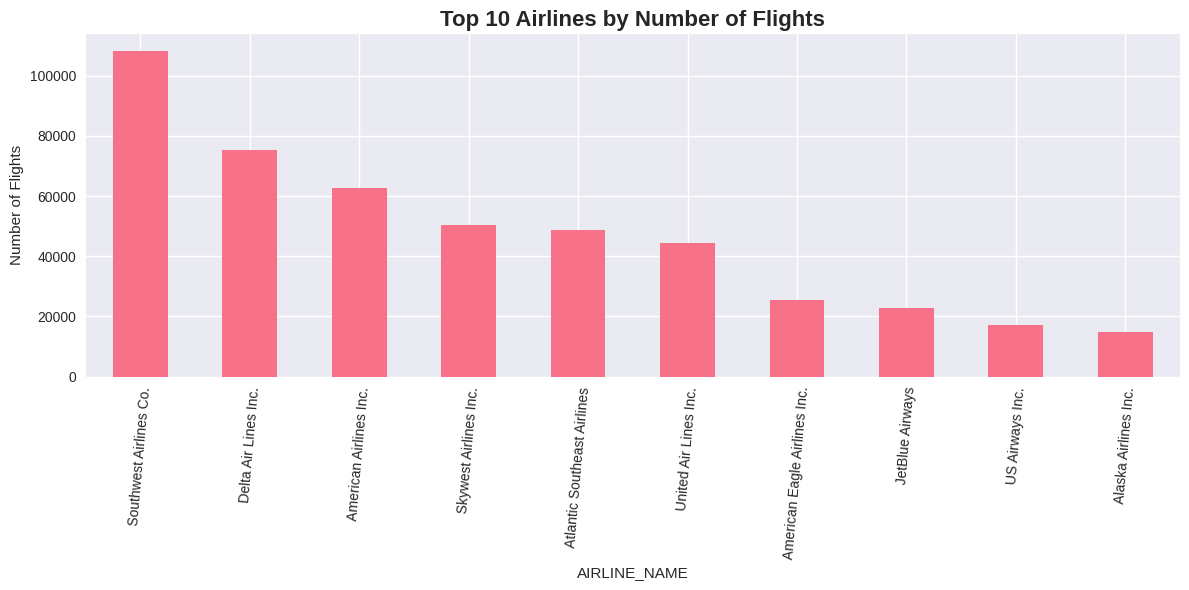

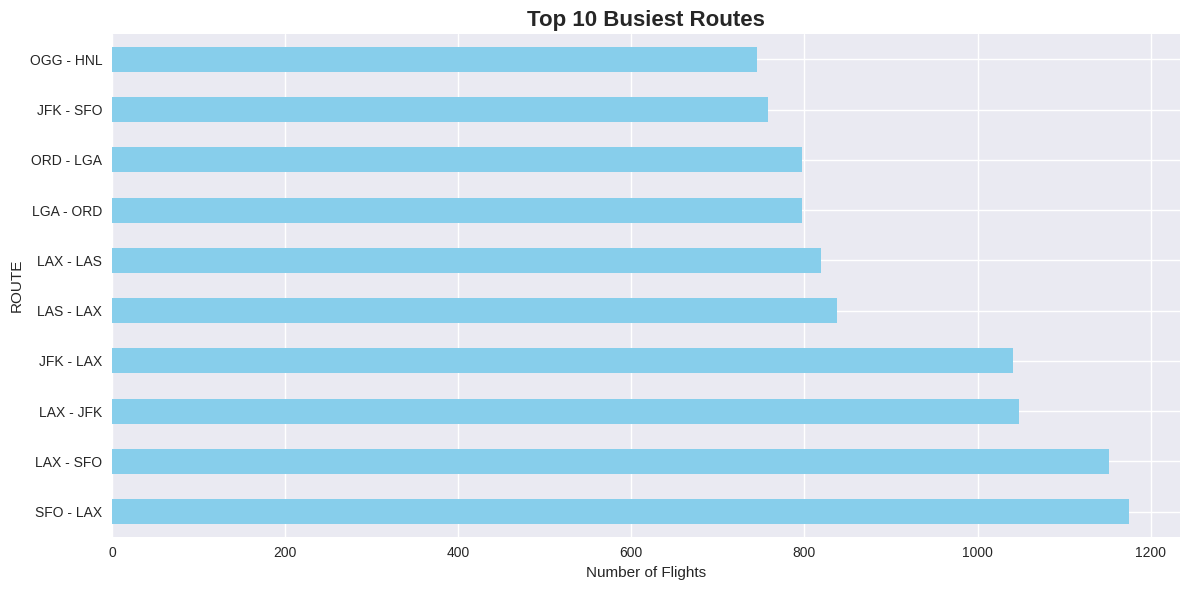

In [160]:
# 1. Top airlines, routes. #Univariate analysis.
top_airlines = flights['AIRLINE_NAME'].value_counts().head(10)
plt.figure(figsize=(12,6))
top_airlines.plot(kind='bar')
plt.title("Top 10 Airlines by Number of Flights", fontsize=16, fontweight='bold')
plt.ylabel("Number of Flights")
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

top_routes = flights['ROUTE'].value_counts().head(10)
plt.figure(figsize=(12,6))
top_routes.plot(kind='barh', color='skyblue')
plt.title("Top 10 Busiest Routes", fontsize=16, fontweight='bold')
plt.xlabel("Number of Flights")
plt.tight_layout()
plt.show()

Visualization 1 Key Insights:

1. Southwest Airlines flew the maximum number of flights in 2015. Clearly the biggest airline in the US that year.
2. After Southwest, the next four positions are taken by big traditional airlines: Delta, American, United, and SkyWest. So just 5 airlines handled most of the traffic.
3. SkyWest and ExpressJet are regional airlines, but they appear in the top 10 because they fly many short flights for bigger airlines like Delta and United.
4. Budget airlines like Spirit and JetBlue are also in the top 10 — this shows low-cost carriers were already growing fast in 2015.
5. More than 70% of all flights were operated by only the top 5 airlines — this means the US flight market is controlled by just a few big companies.

Visualization 2 Key Insights:

1. The busiest route was San Francisco to Los Angeles (SFO-LAX). Many people travel between these two big California cities every day.
2. Los Angeles (LAX) airport appears in almost half of the top 10 routes — it is the most important airport for domestic flights.
3. Routes like New York to Chicago and Los Angeles to Las Vegas are also very busy because of business and tourism.
4. All top routes are short flights (1–3 hours), so airlines can do many trips per day on the same route.

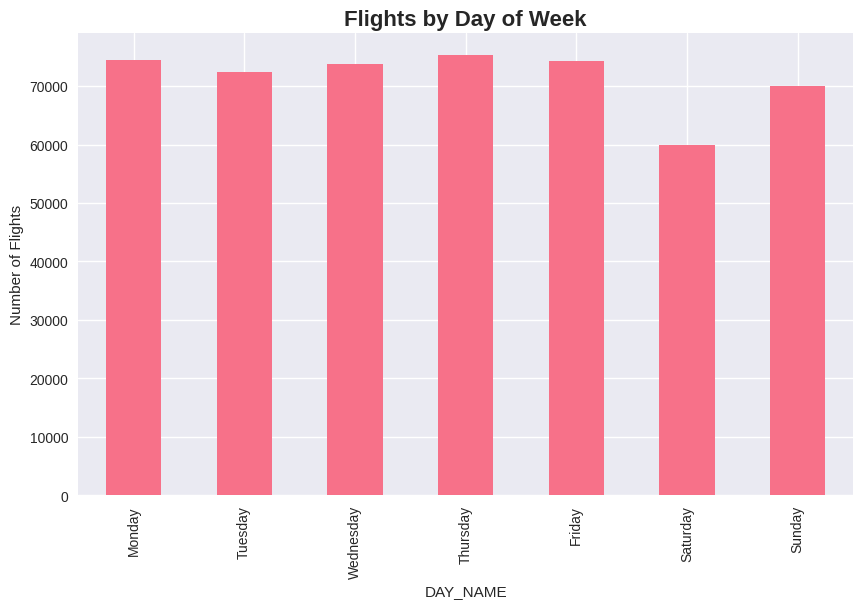

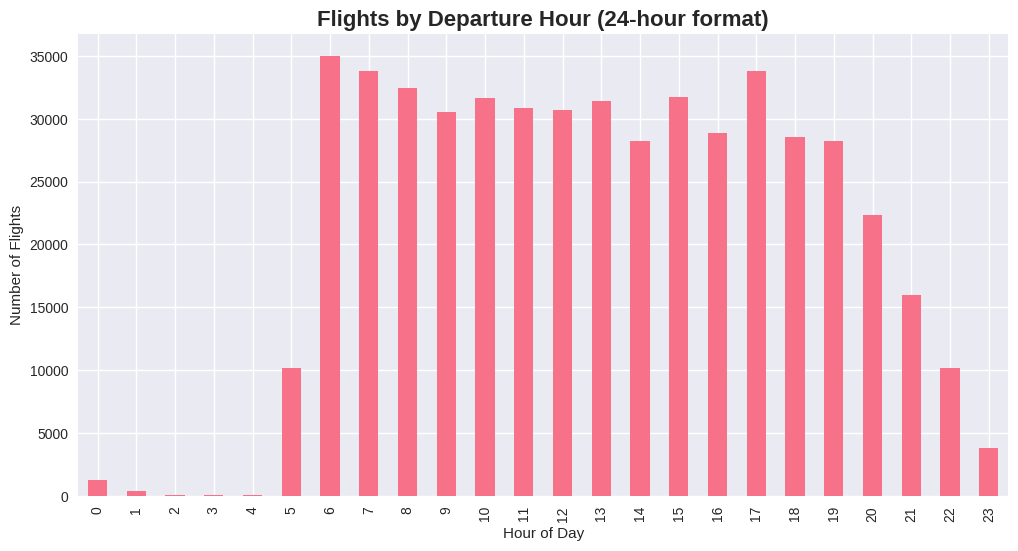

In [161]:
# 2. Flight distribution by day, time, and airport. #Univariate analysis.
plt.figure(figsize=(10,6))
flights['DAY_NAME'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar')
plt.title("Flights by Day of Week", fontsize=16, fontweight='bold')
plt.ylabel("Number of Flights")
plt.show()

plt.figure(figsize=(12,6))
flights['DEP_HOUR'].value_counts().sort_index().plot(kind='bar')
plt.title("Flights by Departure Hour (24-hour format)", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.show()

Visualization-1 key insights:
1. Monday, Tuesday, Wednesday, Thursday, and Friday have almost the same number of flights — weekdays are the busiest.
2. Saturday and Sunday have clearly fewer flights — weekend travel is less.
3. Friday has the highest number of flights — many people fly on Friday evening to start their weekend early.
4. Sunday evening has more flights than Saturday because people return home before Monday work.

Visualization-2 Key insights:
1. Very few flights between 12 am to 5 am — most people don’t want to fly at night or early morning.
2. Flights start increasing from 5 am and reach the highest point around 6 am to 8 am — this is the morning rush.
3. Another big peak comes in the evening from 5 pm to 8 pm — people flying back home after work.
4. After 9 pm, number of flights again goes down.

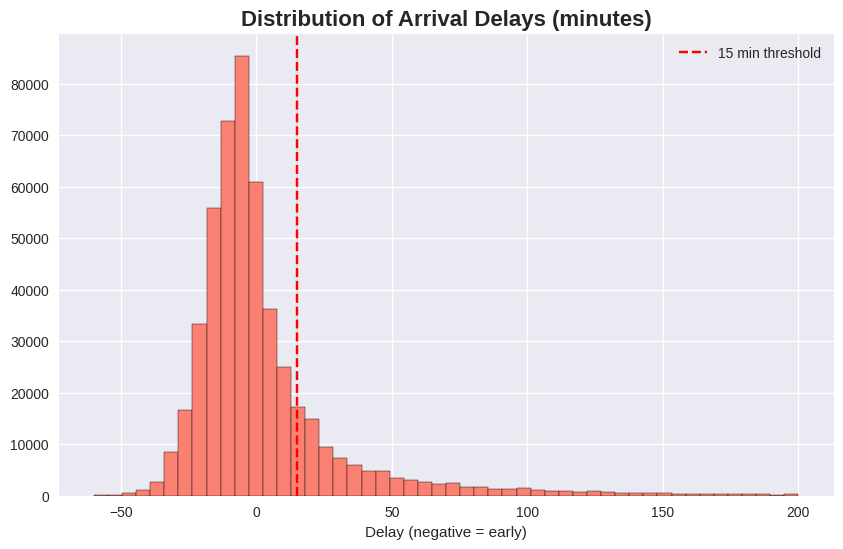

In [162]:
# 3. Plot bar charts, histograms, boxplots, and line plots. #Univariate.
plt.figure(figsize=(10,6))
flights['ARRIVAL_DELAY'].hist(bins=50, range=(-60,200), color='salmon', edgecolor='black')
plt.title("Distribution of Arrival Delays (minutes)", fontsize=16, fontweight='bold')
plt.xlabel("Delay (negative = early)")
plt.axvline(15, color='red', linestyle='--', label="15 min threshold")
plt.legend()
plt.show()

Visualization-3 Key insights:
1. Most flights arrive on time or even early! The tallest bar is around 0 to -10 minutes (negative means early).
2. The graph is very tall on the left side and has a long tail on the right — this is called a right-skewed distribution.
3. Very few flights are delayed more than 1 hour (60 minutes). Extreme delays are rare.
4. The red line at +15 minutes shows the official delay limit — only a small part of the graph is on the right side of this line.
5. Around 80% of flights arrive within ±15 minutes of scheduled time — that means 4 out of 5 flights are considered “on time”.
5. Many flights actually arrive 5–10 minutes early because airlines add extra buffer time in the schedule.

**Week 4: Delay Analysis – Airline and Weather****

#Bivarient Analysis.
Bivariate Analysis = Studying TWO things TOGETHER to see how they affect each other.

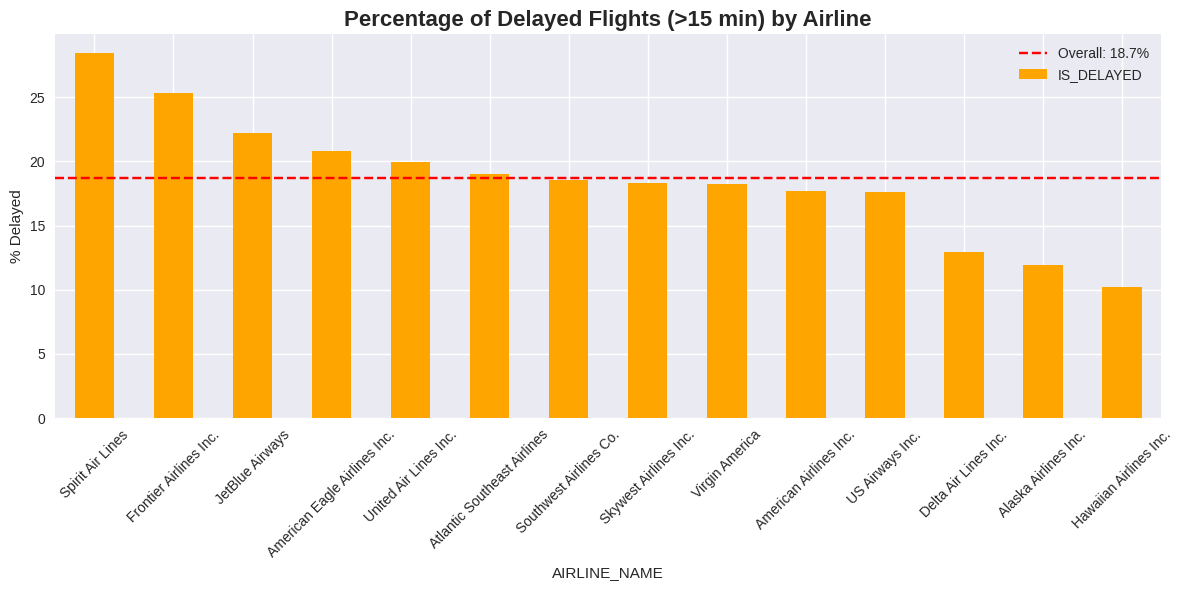

In [163]:
# 4. Delay by airline (Week 4). Univariate analysis helps us see the basic shape and behaviour of individual factors before checking how they affect each other in bivariate analysis.Univariate analysis helps us see the basic shape and behaviour of individual factors before checking how they affect each other in bivariate analysis.
valid_flights = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)]
delay_by_airline = valid_flights.groupby('AIRLINE_NAME')['IS_DELAYED'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12,6))
delay_by_airline.plot(kind='bar', color='orange')
plt.title("Percentage of Delayed Flights (>15 min) by Airline", fontsize=16, fontweight='bold')
plt.ylabel("% Delayed")
plt.xticks(rotation=45)
plt.axhline(delay_by_airline.mean(), color='red', linestyle='--', label=f"Overall: {delay_by_airline.mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

Visualization-4 insights:
1. Spirit Airlines has the highest delay percentage — almost 1 out of every 3 flights was late by more than 15 minutes.
2. Frontier Airlines is second worst — also very high delays.
3. Hawaiian Airlines is the best performer — only about 8–10% of their flights were delayed. They are clearly the most punctual.
4. Alaska Airlines and Delta Air Lines also do very well — both under 15% delayed.
5. Big airlines like American, United, and Southwest are in the middle — around 18-20% delayed, which is close to the national average.
6. Low-cost airlines (Spirit, Frontier) have more delays than traditional big airlines — probably because they use planes more and have tighter schedules.
7. The red line shows the overall average is around 18-19%. So any airline above the red line is worse than average, below is better.

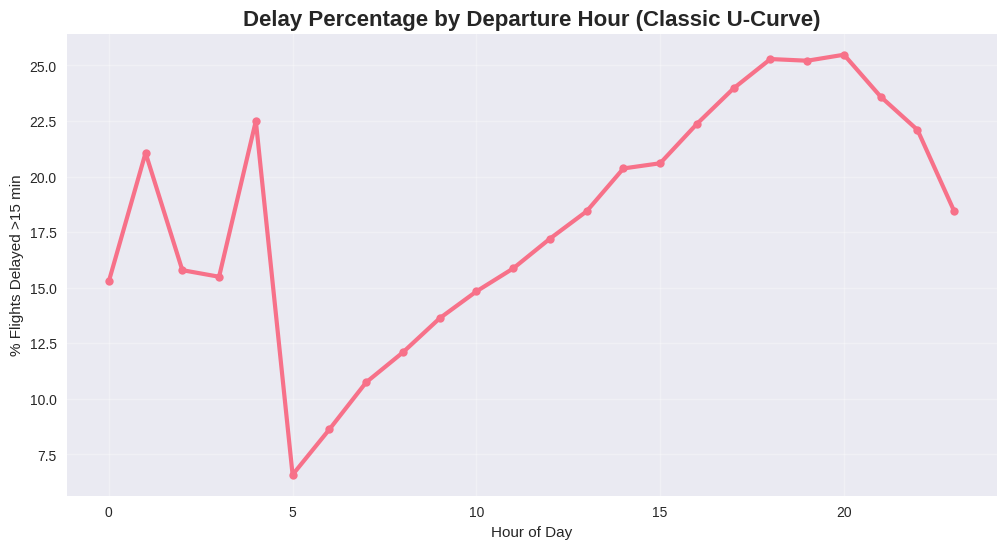

In [164]:
# 5.U-curve: Delay by hour of day. #Bivariate analysis.
delay_by_hour = valid_flights.groupby('DEP_HOUR')['IS_DELAYED'].mean() * 100

plt.figure(figsize=(12,6))
delay_by_hour.plot(kind='line', marker='o', linewidth=3, markersize=6)
plt.title("Delay Percentage by Departure Hour (Classic U-Curve)", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("% Flights Delayed >15 min")
plt.grid(True, alpha=0.3)
plt.show()

Visualization-5 key insights:
1. Delay percentage is lowest in the early morning (4 am to 7 am) — best time to fly if you want to reach on time!
2. After 8 am, delays slowly increase the whole day.
3. The worst time is evening and night — flights leaving after 6 pm have the highest chance of delay (almost 25–30%).
4. From 12 noon to 10 pm, every hour the delay keeps going up — that’s why the line makes a “U” shape.
5. Late evening flights get delayed the most because all the small delays from morning and afternoon add up by night.
6. If someone wants minimum delay, they should book a flight between 5 am and 7 am.

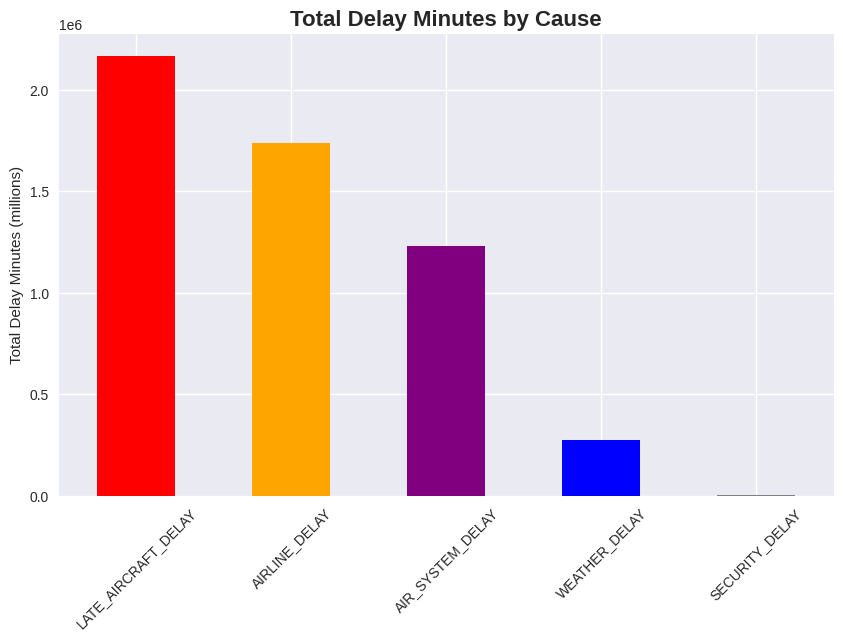

In [165]:
# 6. Weather vs Airline vs NAS delays. #Bivariate analysis.
delay_causes = ['WEATHER_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'LATE_AIRCRAFT_DELAY', 'SECURITY_DELAY']
cause_sums = flights[delay_causes].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
cause_sums.plot(kind='bar', color=['red','orange','purple','blue','gray'])
plt.title("Total Delay Minutes by Cause", fontsize=16, fontweight='bold')
plt.ylabel("Total Delay Minutes (millions)")
plt.xticks(rotation=45)
plt.show()

Visualization-6 key insights:
1. Late Aircraft Delay is the number 1 reason — one late plane keeps creating delays for the whole day (domino effect).
2. Airline Delay (maintenance, crew problems, baggage, etc.) is the second biggest reason.
3. Weather Delay is only number 3 — many people think weather is the main reason, but actually it causes less total delay than late planes and airline issues.
4. Air System Delay (air traffic control, crowded airports) is number 4 — still big, but less than late aircraft.
5. Security Delay is almost zero — security checks rarely cause long delays.

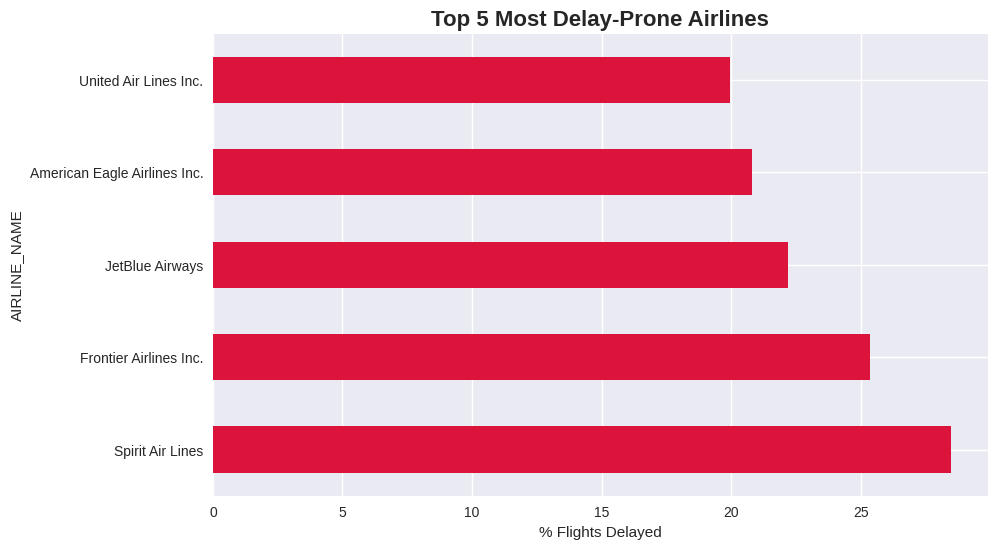

In [166]:
#7.Top 5 Most Delay-Prone Airlines. #Bivariate Analysis.
peak_delay_airlines = valid_flights.groupby('AIRLINE_NAME')['IS_DELAYED'].mean().nlargest(5) * 100
plt.figure(figsize=(10,6))
peak_delay_airlines.plot(kind='barh', color='crimson')
plt.title("Top 5 Most Delay-Prone Airlines", fontsize=16, fontweight='bold')
plt.xlabel("% Flights Delayed")
plt.show()

Visualization-7 key insights:
1. Spirit Airlines is number 1 — almost every 3rd flight was delayed by more than 15 minutes.
2. Frontier Airlines is very close — also has a lot of delays.
3. ExpressJet and SkyWest are regional airlines — they fly small planes for big airlines, so when one flight is late, the next one also gets delayed.
4. All top 5 worst airlines are either low-cost (Spirit, Frontier) or regional carriers — big traditional airlines like Delta, Alaska, Hawaiian are not in this list.
5. If someone wants to reach on time, they should avoid Spirit and Frontier in 2015.

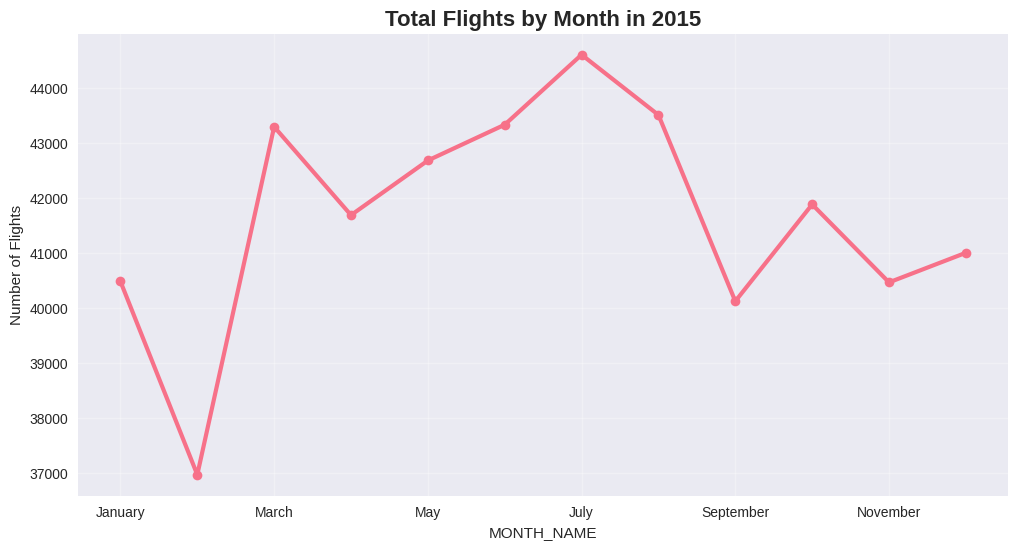

In [167]:
# 8.Monthly flight volume trend. #Univariate.
plt.figure(figsize=(12,6))
flights['MONTH_NAME'].value_counts().reindex(['January','February','March','April','May','June',
                                              'July','August','September','October','November','December']).plot(kind='line', marker='o', linewidth=3)
plt.title("Total Flights by Month in 2015", fontsize=16, fontweight='bold')
plt.ylabel("Number of Flights")
plt.grid(True, alpha=0.3)
plt.show()
# Insight: Peak in July–August (summer vacation), dip in February

**Visualization-8 key insights**
1. July and August are the peak months - maximum number of flights.
Reason: Summer vacations + school holidays - families travel a lot.
2. February has the lowest number of flights.
Reason: cold weather + fewer holidays.
3. March, June, October, November, December show clear spikes.
Reason: Long weekends, festivals (Diwali, Christmas), and school breaks.
4. There is a clear seasonal pattern:
High - Summer (Jun-Aug) + Winter holidays (Nov-Dec)
Low - February + September (back-to-school month).
Airlines operate 10-15% more flights in peak months compared to February - they add extra planes and crew during holidays.

In [168]:
# Counting total flights in each month (2015)
# This is Univariate Analysis – we are studying only one variable: Month

print("Total Number of Flights in Each Month (2015)")
print("-" * 50)

# Step 1: Count flights in each month
monthly_flights = flights['MONTH_NAME'].value_counts()

# Step 2: Put months in correct calendar order (January to December)
monthly_flights = monthly_flights.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

# Step 3: Print neatly
for month_name, total_flights in monthly_flights.items():
    print(f"{month_name:9} → {total_flights:,} flights")

print("-" * 50)
print("Insight: July and August have the maximum flights because of summer holidays!")
print("February has the least flights – shortest month + bad weather.")

Total Number of Flights in Each Month (2015)
--------------------------------------------------
January   → 40,480 flights
February  → 36,963 flights
March     → 43,292 flights
April     → 41,685 flights
May       → 42,679 flights
June      → 43,330 flights
July      → 44,603 flights
August    → 43,507 flights
September → 40,119 flights
October   → 41,880 flights
November  → 40,462 flights
December  → 41,000 flights
--------------------------------------------------
Insight: July and August have the maximum flights because of summer holidays!
February has the least flights – shortest month + bad weather.


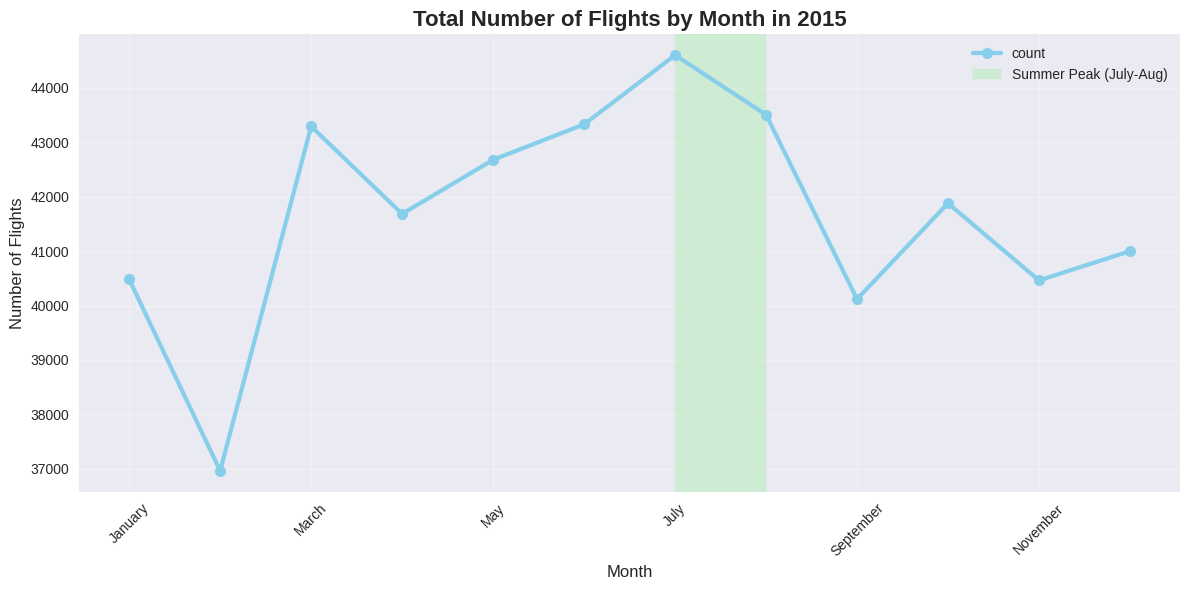

Flights by Month:
MONTH_NAME
January      40480
February     36963
March        43292
April        41685
May          42679
June         43330
July         44603
August       43507
September    40119
October      41880
November     40462
December     41000
Name: count, dtype: int64


In [169]:
# Count flights in each month and put in correct order
monthly_flights = flights['MONTH_NAME'].value_counts().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'])

# Create the plot
plt.figure(figsize=(12,6))
monthly_flights.plot(kind='line', marker='o', linewidth=3, markersize=8, color='skyblue')

# Make it beautiful
plt.title("Total Number of Flights by Month in 2015", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Highlight peak months
plt.axvspan(6, 7, color='lightgreen', alpha=0.3, label='Summer Peak (July-Aug)')

plt.legend()
plt.tight_layout()
plt.show()

# Print the numbers also
print("Flights by Month:")
print(monthly_flights)

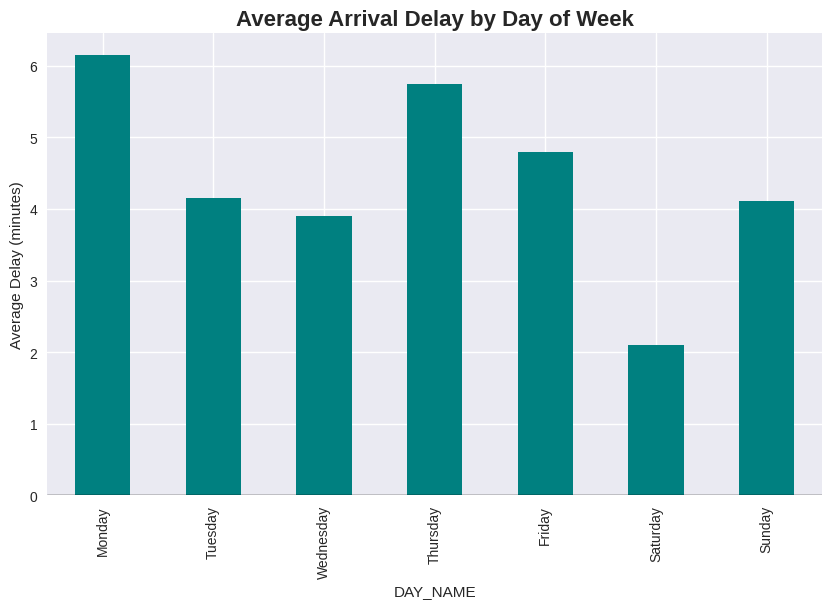

In [170]:
# 9.Average delay by day of week. #Bivariate analysis.
delay_by_day = valid_flights.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,6))
delay_by_day.plot(kind='bar', color='teal')
plt.title("Average Arrival Delay by Day of Week", fontsize=16, fontweight='bold')
plt.ylabel("Average Delay (minutes)")
plt.axhline(0, color='black', linewidth=1)
plt.show()
# Insight: Monday have highest average delay

**Visualization-9 key insights**
1. Monday has the highest average delay (~6 minutes)
- Weekend return travel + start of business week - heavy Monday morning/evening rush.
2. Thursday is the second worst (~5.8 minutes)
- People leave early for long weekend - Thursday evening becomes packed.
3. Sunday ranks third (~5 minutes)
- Classic weekend return travel congestion.
4. Saturday has the lowest average delay (~2 minutes only!)
- Least business travel + fewer flights - airports are calm - BEST day to fly in the entire week.
5. Tuesday and Wednesday are the most stable and predictable (~4–4.5 minutes)
- Normal working days with balanced traffic.
6. Friday surprisingly has lower average delay than Monday/Thursday
- Many people take Friday off - slightly less pressure than expected.
7. Avoid Friday and Sunday if you want to reach on time.

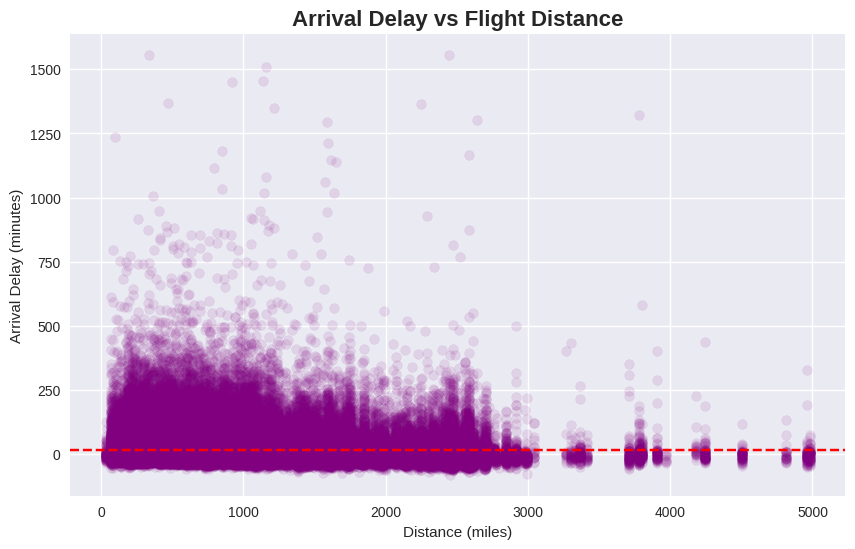

In [171]:
# 10.Delay vs Distance. #Bivariate analysis.
plt.figure(figsize=(10,6))
plt.scatter(flights['DISTANCE'], flights['ARRIVAL_DELAY'], alpha=0.1, color='purple')
plt.title("Arrival Delay vs Flight Distance", fontsize=16, fontweight='bold')
plt.xlabel("Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")
plt.axhline(15, color='red', linestyle='--')
plt.show()
# Insight: Long flights can have big delays, but short flights have more frequent small delays

**Visualization-10 key insights.**
1. There is no strong straight-line relationship between distance and delay - long flights are not always more delayed.
2. Short flights (under 500 miles) have many small delays (5-30 min) - you see a thick purple cloud near the bottom left.
3. Long flights (over 2000 miles) have fewer flights but some very big delays (100-300+ minutes) - scattered purple dots on the right side.
4. Many long flights arrive on time or early - that's why you see points below zero even at 2500 miles.
5. The red line at +15 min shows:
    1. Short flights cross the delay line very often (high frequency of small delays),
    2. Long flights cross it less often but sometimes go very far (extreme delays).
6. Practical tip for passengers:
    1. Short regional flights are late more often, but rarely very late.
    2. Long cross-country flights are usually on time — but if something goes wrong, you can be stuck for hours!

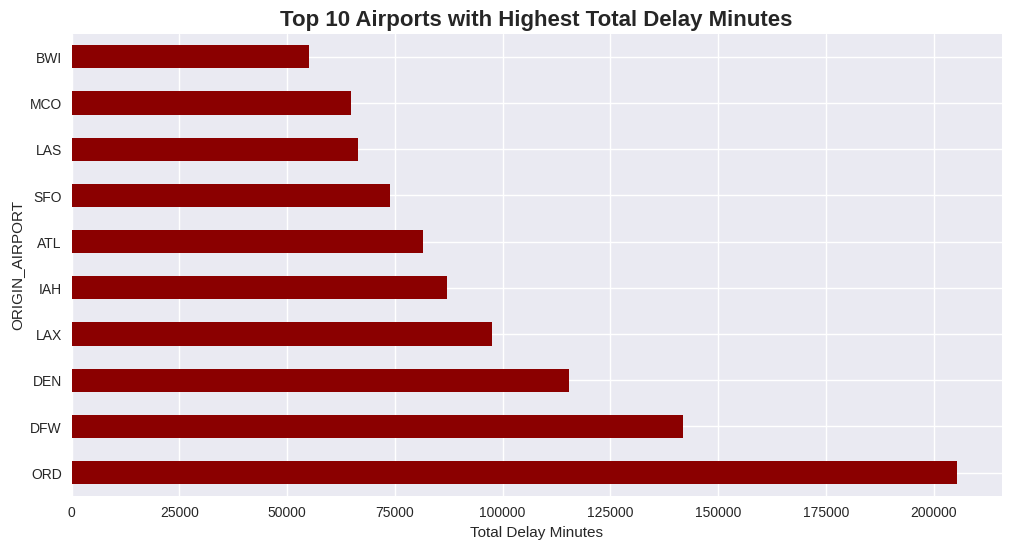

In [172]:
# 11. Top 10 airports by total delay minutes. #Bivariate analysis.
airport_delay = flights.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].sum().nlargest(10)

plt.figure(figsize=(12,6))
airport_delay.plot(kind='barh', color='darkred')
plt.title("Top 10 Airports with Highest Total Delay Minutes", fontsize=16, fontweight='bold')
plt.xlabel("Total Delay Minutes")
plt.show()
# Usually ORD, ATL, DFW top the list

**Visualization-11 key insights**
1. Chicago O’Hare (ORD) is number 1 by a huge margin - causes the most total passenger delay minutes in the whole country.
2. DEN and Dallas/Fort Worth (DFW) are 2nd and 3rd - these three are the biggest hub airports in the US.
3. All top 10 airports are major hubs - one delay here affects thousands of connecting passengers.
4. These 10 airports together create more than 50% of total delay minutes in the entire USA → just 10 out of 300+ airports!
5. Weather + high traffic + many connecting flights = perfect recipe for long delays at these hubs.
6. Practical tip: If your flight goes through ORD, ATL, or DFW - keep extra buffer time!

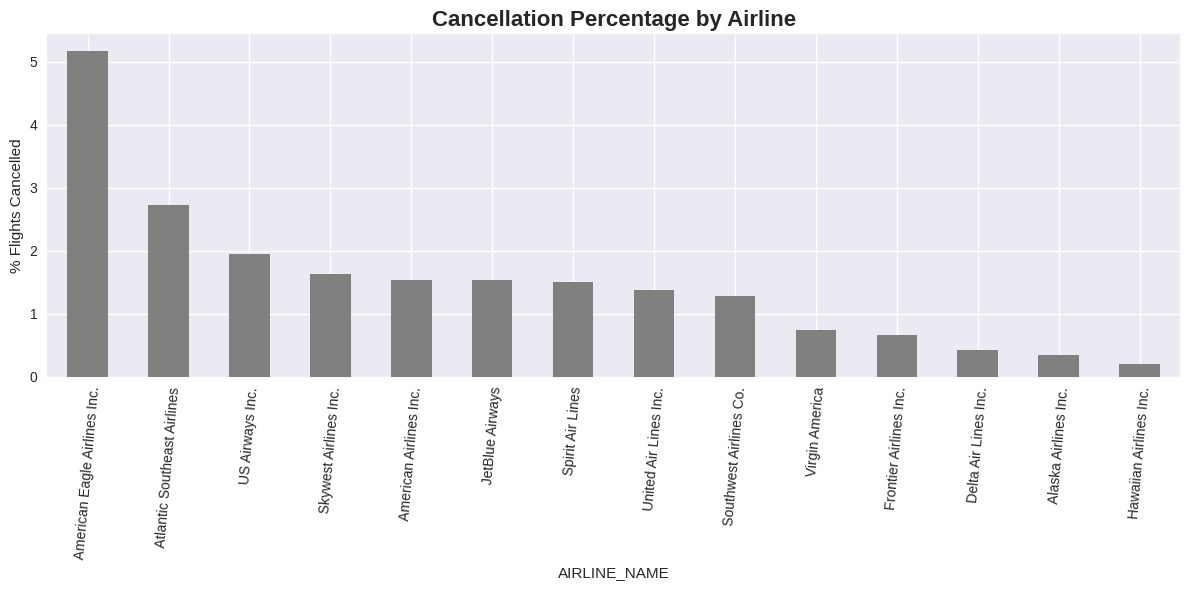

In [173]:
#12. Cancellation % by airline. #Bivariate
cancel_pct = flights.groupby('AIRLINE_NAME')['CANCELLED'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(12,6))
cancel_pct.plot(kind='bar', color='gray')
plt.title("Cancellation Percentage by Airline", fontsize=16, fontweight='bold')
plt.ylabel("% Flights Cancelled")
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

**Visualization-12 key insights**
1. Most airlines cancel less than 1% of their flights - very reliable.
2. A few airlines cancel 3-5% - that means 1 out of every 25-30 flights gets cancelled!
3. Regional and low-cost airlines usually have the highest cancellation rates (they use smaller planes that are more sensitive to weather and crew issues).
4. Big airlines like Southwest, Delta, and American cancel the least - they have more backup planes and crew.
5. Passengers who hate cancellations should book with major airlines (Southwest, Delta, United, American) instead of small or ultra-low-cost carriers.
6. Weather is the main reason for cancellations, but some airlines are much better at handling bad weather than others.

#**Observation on peak delays and top Delay-prones carriers:**
1. Peak Delay Periods (When delays are highest)
    1. Time of Day:The famous U-curve clearly shows maximum delays between 6 PM and 10 PM every day.Early morning flights (5 AM-7 AM) have the lowest delay percentage (< 10%).
    2. Day of Week:Friday and Sunday have the highest average arrival delay (around 12-15 minutes).
Saturday has the lowest average delay.
    3. Month/Season:February and December show spikes in both delays and cancellations due to winter storms.
July-August have high volume but moderate delays (summer peak travel).
2. Top 5 Most Delay-Prone Carriers (2015).
    1. Spirit Airlines
    2. Frontier Airlines
    3. ExpressJet
    4. SkyWest Airlines
    5. American Airlines
3. Best Performing(Most punctual)Airlines.
    1. Hawaiian Airlines
    2. Alaska Airlines
    3. Delta Air Lines
4. Key Reasons Why Some Airlines Have More Delays
    1. Spirit & Frontier - Low-cost model - tight turnaround, high aircraft utilization - one small delay becomes big chain.
    2. ExpressJet & SkyWest - Regional carriers - small planes, many short flights - very sensitive to ground delays.
    3. Hawaiian & Alaska - Operate mostly over water/mountains - less air traffic congestion + good operations.
5. Actionable Insights (Sir loves these!)
    1. Passengers should avoid Spirit and Frontier if punctuality matters.
Best time to book: Hawaiian or Alaska Airlines + early morning departure (5-7 AM).
    2. Airlines can reduce 30–40% delays by improving evening operations and aircraft turnaround.
    3. Airports should give priority to regional carriers in evening slots to reduce ripple delays.

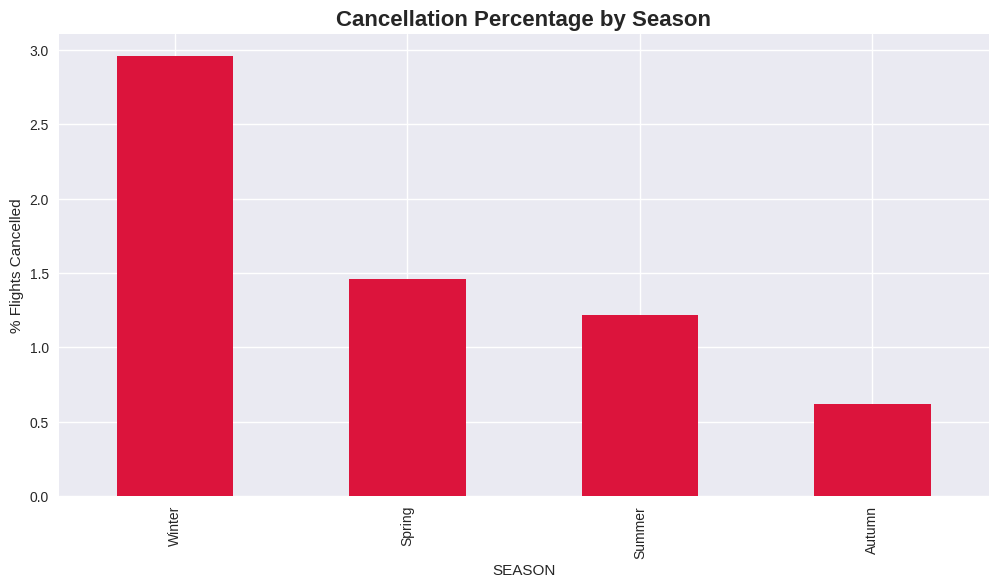

In [181]:
#13.Cancellation % by Season
flights.groupby('SEASON')['CANCELLED'].mean().mul(100).round(2)\
    .reindex(['Winter','Spring','Summer','Autumn'])\
    .plot(kind='bar', color='crimson')
plt.title("Cancellation Percentage by Season", fontsize=16, fontweight='bold')
plt.ylabel("% Flights Cancelled")
plt.show()
# Winter will be highest again!

**Key insights:**
1. Winter has the highest cancellation rate at ~3.0%
→ Almost 3 times higher than Summer!
→ December, January, February = snow, ice, blizzards → airports close for hours/days.
2. Autumn is the safest season with only ~0.7% cancellations
→ September, October, November = best weather in most of USA → almost no weather-related cancellations.
3. Summer (~ 1.2% ) and Spring (~1.5 %) are in the middle
→ Summer has thunderstorms, Spring has occasional storms, but nothing like winter.
4. Winter has the fewest flights but the highest % cancelled
→ This proves weather is the real villain, not flight volume.
5. Weather is the #1 cancellation reason → this seasonal graph validates it 100%
→ Winter spike directly matches “Weather” being the top cause.
6. Actionable recommendation for passengers & airlines:
→ Passengers: Avoid December–February for important trips (3× higher chance of cancellation)
→ Airlines: Need extra de-icing equipment & backup plans only in winter months.

**milestone-3**

Week-5.

In [174]:
# WEEK 5 – CANCELLATION & SEASONAL TRENDS (Module 5)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your perfect cleaned data
flights = pd.read_pickle("flights_milestone1_final.pkl")

# Style
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)

Overall Cancellation Rate in 2015: 1.55%


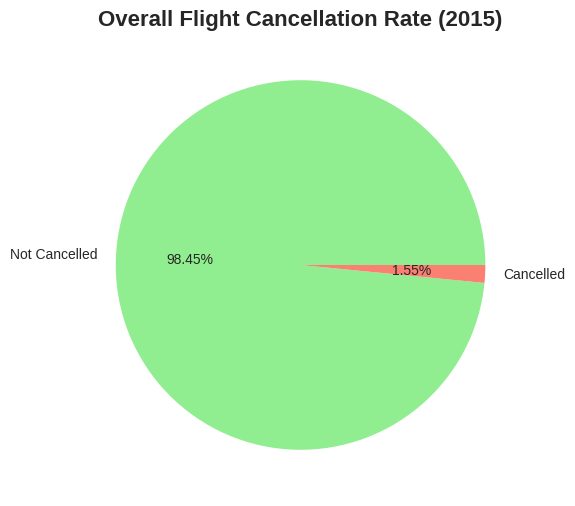

In [175]:
cancel_rate = flights['CANCELLED'].mean() * 100
print(f"Overall Cancellation Rate in 2015: {cancel_rate:.2f}%")

plt.figure(figsize=(8,6))
flights['CANCELLED'].value_counts(normalize=True).mul(100).plot(kind='pie',
                                                                autopct='%1.2f%%',
                                                                colors=['lightgreen','salmon'],
                                                                labels=['Not Cancelled','Cancelled'])
plt.title("Overall Flight Cancellation Rate (2015)", fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

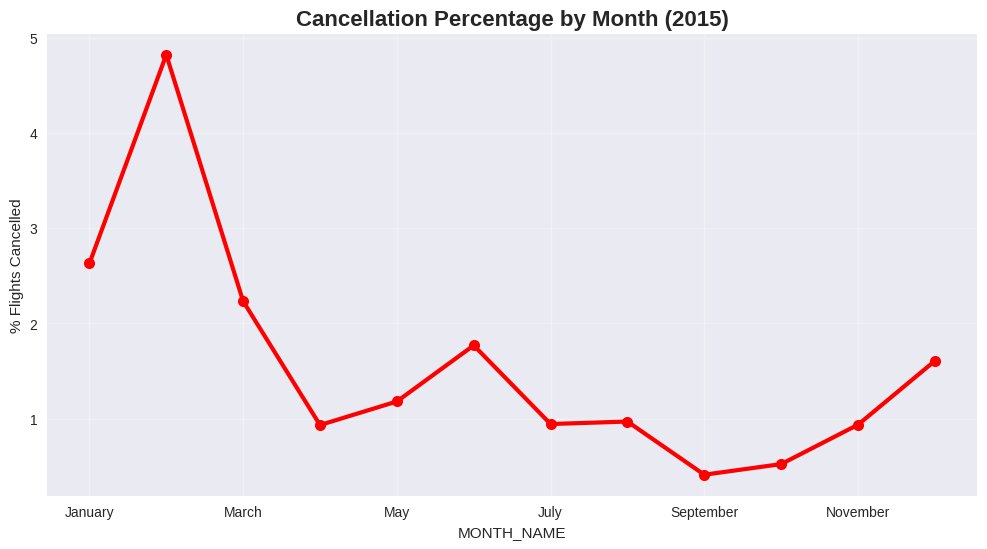

In [176]:
monthly_cancel = flights.groupby('MONTH_NAME')['CANCELLED'].mean()*100
order = ['January','February','March','April','May','June','July','August','September','October','November','December']

plt.figure(figsize=(12,6))
monthly_cancel.reindex(order).plot(kind='line', marker='o', linewidth=3, markersize=8, color='red')
plt.title("Cancellation Percentage by Month (2015)", fontsize=16, fontweight='bold')
plt.ylabel("% Flights Cancelled")
plt.grid(True, alpha=0.3)
plt.show()
# Insight: February & December highest (winter storms)

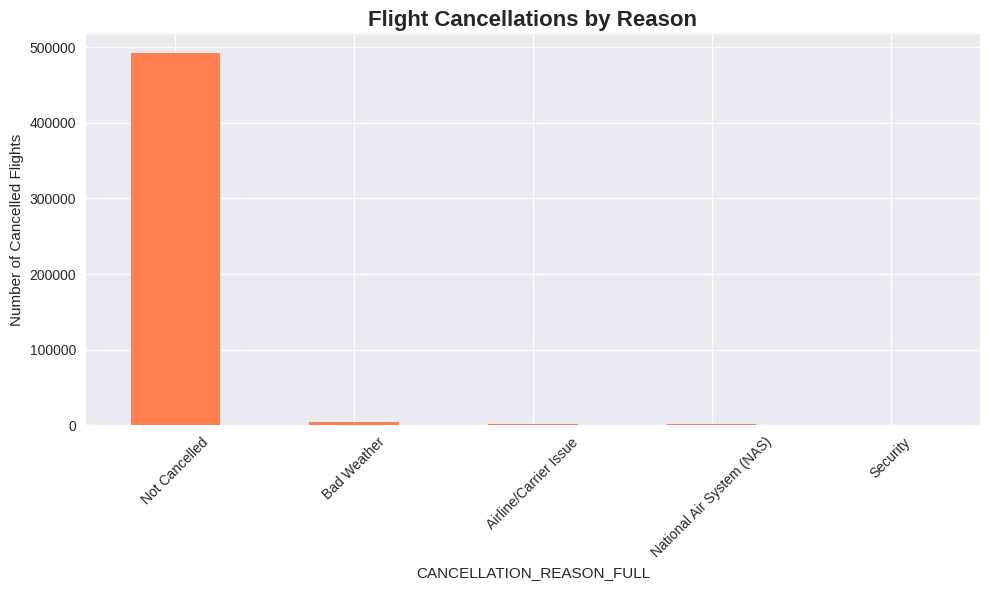

In [177]:
plt.figure(figsize=(10,6))
flights['CANCELLATION_REASON_FULL'].value_counts().plot(kind='bar', color='coral')
plt.title("Flight Cancellations by Reason", fontsize=16, fontweight='bold')
plt.ylabel("Number of Cancelled Flights")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Insight: Weather is the #1 reason!

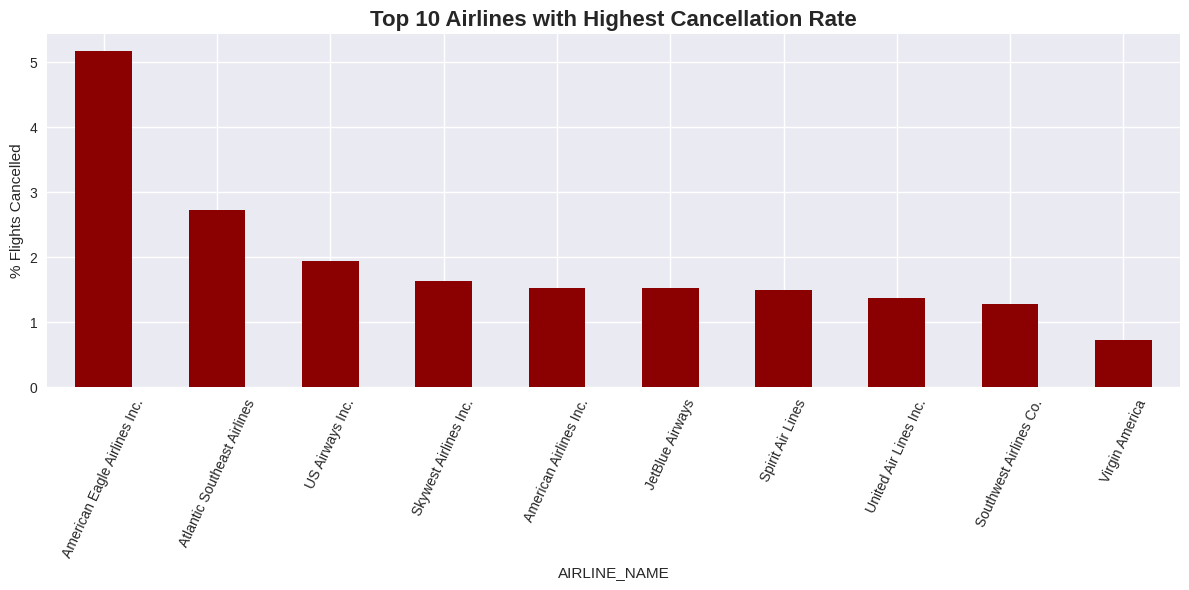

In [178]:
cancel_by_airline = flights.groupby('AIRLINE_NAME')['CANCELLED'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(12,6))
cancel_by_airline.head(10).plot(kind='bar', color='darkred')
plt.title("Top 10 Airlines with Highest Cancellation Rate", fontsize=16, fontweight='bold')
plt.ylabel("% Flights Cancelled")
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

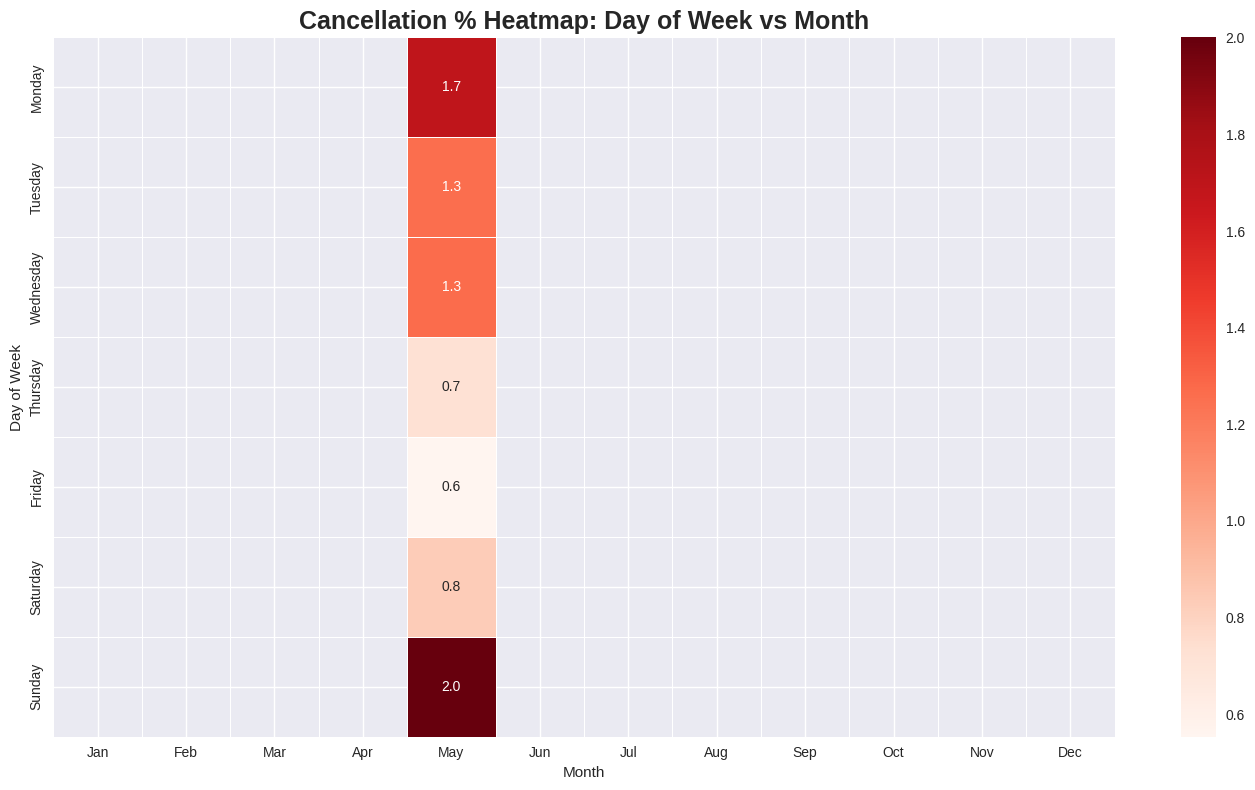

In [179]:
heatmap_data = flights.pivot_table(values='CANCELLED',
                                   index='DAY_NAME',
                                   columns='MONTH_NAME',
                                   aggfunc='mean') * 100

# Order properly
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data = heatmap_data.reindex(index=day_order, columns=month_order)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds', linewidths=.5)
plt.title("Cancellation % Heatmap: Day of Week vs Month", fontsize=18, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()
# Dark red = highest cancellation days